## Topic: Practical Implementation of Persistence in LangGraph


In [ ]:
"""
- workflows:
    - topic ---> joke generate (LLM) ---> Explanation of joke (LLM)---> final response

"""

In [18]:
# import necessary Library
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from typing import TypedDict, Annotated

from langchain_groq import ChatGroq
from dotenv import load_dotenv


In [19]:
load_dotenv()

True

In [20]:
# Define the LLM for chat_node
llm =  ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [21]:
# 1. Define State
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [22]:
# 3. Define node (gen_joke)
def gen_joke(state: JokeState) -> dict:
    """ Generate a Joke based on Given topic """
    prompt = f"generate a joke on the topic {state['topic']}"

    response = llm.invoke(prompt).content

    return {
        "joke": response
    }


In [23]:
# 4. Define node (exp_joke)
def exp_joke(state: JokeState) -> dict:
    """ Explain a Joke based on Given Joke """
    prompt = f"Write an explanation on the joke {state['joke']}"

    response = llm.invoke(prompt).content

    return {
        "explanation": response
    }


In [24]:
# 2. Define graph
graph = StateGraph(JokeState)


# nodes
graph.add_node("generate_joke", gen_joke)
graph.add_node("explanation_joke", exp_joke)

# edges
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explanation_joke")
graph.add_edge("explanation_joke", END)



# 5. Define memory
memory = InMemorySaver()


# 6. compile the workflow
workflow = graph.compile(checkpointer=memory)


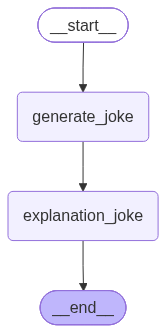

In [25]:
workflow

In [30]:
# 7. config with Thread_ID
config1 = {
    "configurable":{"thread_id": "1"}
}


# 8. execute the workflow
response = workflow.invoke({
    "topic": "Cricket"
    }, config= config1)


In [31]:
response

{'topic': 'Cricket',
 'joke': 'Why did the cricket team bring a ladder to the match?\n\nBecause they heard the wickets were *high* stakes!',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|---------------------------------|\n| **The set‑up** | “Why did the cricket team bring a ladder to the match?” | It’s a classic “why did X do Y?” question that primes the listener for a punchline that is a play on words. |\n| **The sport** | Cricket | In cricket the “wickets” are the stumps and bails that the bowlers try to hit. The term “wicket” is a key piece of cricket vocabulary, so the joke is only funny to people who know what a wicket is. |\n| **The punchline** | “Because they heard the wickets were *high* stakes!” | Two layers of wordplay are at work: |\n| | 1. **High stakes** is an idiom meaning “a situation with a lot at risk” (e.g., a high‑stakes game). | The joke starts with the familiar phr

In [32]:
# Fetch the final state value of the workflow
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the match?\n\nBecause they heard the wickets were *high* stakes!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|---------------------------------|\n| **The set‑up** | “Why did the cricket team bring a ladder to the match?” | It’s a classic “why did X do Y?” question that primes the listener for a punchline that is a play on words. |\n| **The sport** | Cricket | In cricket the “wickets” are the stumps and bails that the bowlers try to hit. The term “wicket” is a key piece of cricket vocabulary, so the joke is only funny to people who know what a wicket is. |\n| **The punchline** | “Because they heard the wickets were *high* stakes!” | Two layers of wordplay are at work: |\n| | 1. **High stakes** is an idiom meaning “a situation with a lot at risk” (e.g., a high‑stakes game). | The joke starts wi

In [33]:
# Get the all intermediate state values

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the match?\n\nBecause they heard the wickets were *high* stakes!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|---------------------------------|\n| **The set‑up** | “Why did the cricket team bring a ladder to the match?” | It’s a classic “why did X do Y?” question that primes the listener for a punchline that is a play on words. |\n| **The sport** | Cricket | In cricket the “wickets” are the stumps and bails that the bowlers try to hit. The term “wicket” is a key piece of cricket vocabulary, so the joke is only funny to people who know what a wicket is. |\n| **The punchline** | “Because they heard the wickets were *high* stakes!” | Two layers of wordplay are at work: |\n| | 1. **High stakes** is an idiom meaning “a situation with a lot at risk” (e.g., a high‑stakes game). | The joke starts w

- Key Note:
    - Here, this memory for thread_id': '1

In [34]:
# Now thread_id': '2'

config2 = {
    "configurable": {"thread_id": "2"}
}

# execute with thread_id : 2
response1 = workflow.invoke({
    "topic": "Football"
}, config= config2)


In [35]:
# response for thread_id 2: 
response1

{'topic': 'Football',
 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖',
 'explanation': ''}

In [36]:
# Fetch the final state response
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf4e3-cc31-65f9-8002-a230a46c6863'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-03T17:16:57.296844+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf4e3-b4af-6fcd-8001-10c3a9454d2b'}}, tasks=(), interrupts=())

In [37]:
# Fetch the all intermediate state values
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf4e3-cc31-65f9-8002-a230a46c6863'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-03T17:16:57.296844+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf4e3-b4af-6fcd-8001-10c3a9454d2b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football team go to the bakery?\n\nBecause they heard they needed a good *roll* to win the championship! 🏈🥖'}, next=('explanation_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf4e3-b4af-6fcd-8001-10c3a9454d2b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-10-03T17:16:54.8